| No.  | Empirical question  | Main data  | Required output  |
| :--- | :--- | :--- | :--- |
| 1  | When did modern economic growth begin in the assigned country?  | Maddison, WDI, national statistics  | Plot GDP per capita over the longest available period, preferably in both level and log scale.  Identify whether growth was stagnant, gradual, or explosive.  |
| 2  | What is the country’s long-run growth story?  | Maddison, WDI, historical sources, national statistics  | Divide the country’s history into major growth regimes: stagnation, take-off, crisis, recovery, acceleration, slowdown.  Students must link the graph to historical events.  |
| 3  | Was the country a growth miracle, a normal grower, or a growth disappointment?  | Maddison, WDI, WEO  | Compare GDP per capita growth with 3–5 benchmark countries.  This follows the slide logic comparing rich countries, middle-income countries, poor countries, growth miracles, and growth disasters.  |
| 4  | Is there evidence of convergence?  | Maddison, WDI  | Plot the country’s GDP per capita relative to a benchmark country or group, such as the United States, Germany, Japan, Korea, ASEAN average, or world average.  Assess whether the income gap narrowed, widened, or remained persistent.  Relate the result to the Solow idea of convergence.  |
| 5  | Does capital accumulation explain the country’s growth?  | EUKLEMS, WDI, WEO  | Plot investment rate, capital per worker, GDP per worker, and capital-output ratio.  Discuss whether physical capital accumulation appears central, as in the Solow model.  |
| 6  | Does the country satisfy Kaldor’s facts?  | EUKLEMS, WDI, national statistics  | Check: output per capita, capital intensity, capital-output ratio, real wages, profit rate if available, and labor/capital income shares.  |
| 7  | What is the role of productivity growth?  | EUKLEMS, WDI  | Decompose growth into labor input, capital deepening, and productivity/TFP.  Ask whether the country’s growth is mainly extensive, capital-driven, or productivity-driven.  |
| 8  | How volatile is the country’s business cycle?  | WEO, national statistics, WDI  | Apply an HP filter to log real GDP.  Plot actual GDP, trend GDP, and the cyclical component.  This follows the slide treatment of trend and cyclical deviations in business-cycle analysis.  |
| 9  | What do Burns–Mitchell diagrams reveal about GDP, investment, and consumption?  | Quarterly national accounts, WEO if annual only  | Identify peaks and troughs, then plot average behavior from 10 quarters before to 10 quarters after each peak.  The slides define Burns–Mitchell diagrams as a way to reveal typical output dynamics and co-movement across macro variables.  |
| 10  | Are fiscal and external variables stabilizing or destabilizing over the cycle?  | WEO, WDI, national statistics  | Construct Burns–Mitchell diagrams or cyclical correlations for government expenditure, trade balance, inflation, and possibly interest rates.  Discuss whether fiscal policy appears countercyclical or procyclical.  |

BMAK 2026 empircal project 

# BMAK 2026: Uruguay Macroeconomic Empirical Analysis

This notebook conducts a comprehensive macroeconomic empirical analysis of the nation of **Uruguay** following the structured 10-question empirical framework. It utilizes datasets `Q1.csv` through `Q10.csv` and draws theoretical insights from the course slides (Parts 2, 3, 4.1–4.3, 5.1–5.2).

**Author:** Antigravity AI  
**Date:** June 2026

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.filters.hp_filter import hpfilter

# Set premium styling for visual excellence
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'lines.linewidth': 2.2,
    'figure.figsize': (10, 6)
})

def clean_data(file_path):
    """
    Cleans and preprocesses annual macroeconomic CSV datasets.
    """
    df = pd.read_csv(file_path)
    df.rename(columns={df.columns[0]: 'Year'}, inplace=True)
    # Remove placeholder rows containing '..'
    df = df[~df.iloc[:, 1].astype(str).str.contains(r'\.\.')]
    df = df.dropna(subset=[df.columns[1]], how='all')
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
    
    # Interpolate missing years in the index
    for i in range(len(df)):
        if pd.isna(df.iloc[i, 0]):
            if i > 0:
                df.iloc[i, 0] = df.iloc[i-1, 0] + 1
    df['Year'] = df['Year'].astype(int)
    
    # Convert value columns to numeric
    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df.reset_index(drop=True)

def clean_q7(file_path):
    """
    Cleans growth accounting percentage dataset.
    """
    df = pd.read_csv(file_path)
    df.rename(columns={df.columns[0]: 'Year'}, inplace=True)
    df = df[~df.iloc[:, 1].astype(str).str.contains(r'\.\.')]
    df = df.dropna(subset=[df.columns[1]], how='all')
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype(int)
    for col in df.columns[1:]:
        df[col] = df[col].astype(str).str.replace('%', '', regex=False).str.strip()
        df[col] = pd.to_numeric(df[col], errors='coerce') / 100.0
    return df.reset_index(drop=True)

def calculate_bm(df, var_name, peaks, k=3):
    """
    Constructs Burns-Mitchell diagram deviations for level variables.
    """
    all_deviations = []
    for peak in peaks:
        matching_rows = df[df['Year'] == peak]
        if len(matching_rows) == 0:
            continue
        idx = matching_rows.index[0]
        if idx - k >= 0 and idx + k < len(df):
            window = df.loc[idx - k : idx + k, var_name].values
            grand_avg = np.mean(window)
            if grand_avg != 0:
                deviation = ((window - grand_avg) / grand_avg) * 100.0
            else:
                deviation = np.zeros_like(window)
            all_deviations.append(deviation)
    return np.mean(all_deviations, axis=0)

def calculate_bm_ratio(df, var_name, peaks, k=3):
    """
    Constructs Burns-Mitchell diagram deviations for ratio variables (percentage point deviation).
    """
    all_deviations = []
    for peak in peaks:
        matching_rows = df[df['Year'] == peak]
        if len(matching_rows) == 0:
            continue
        idx = matching_rows.index[0]
        if idx - k >= 0 and idx + k < len(df):
            window = df.loc[idx - k : idx + k, var_name].values
            grand_avg = np.mean(window)
            deviation = (window - grand_avg) * 100.0
            all_deviations.append(deviation)
    return np.mean(all_deviations, axis=0)

## <span style = 'color:red'> Question 1: When did modern economic growth begin in Uruguay?

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_14860\2842447635.py:27: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  axes[1].grid(False, linestyle='--', alpha=0.6)


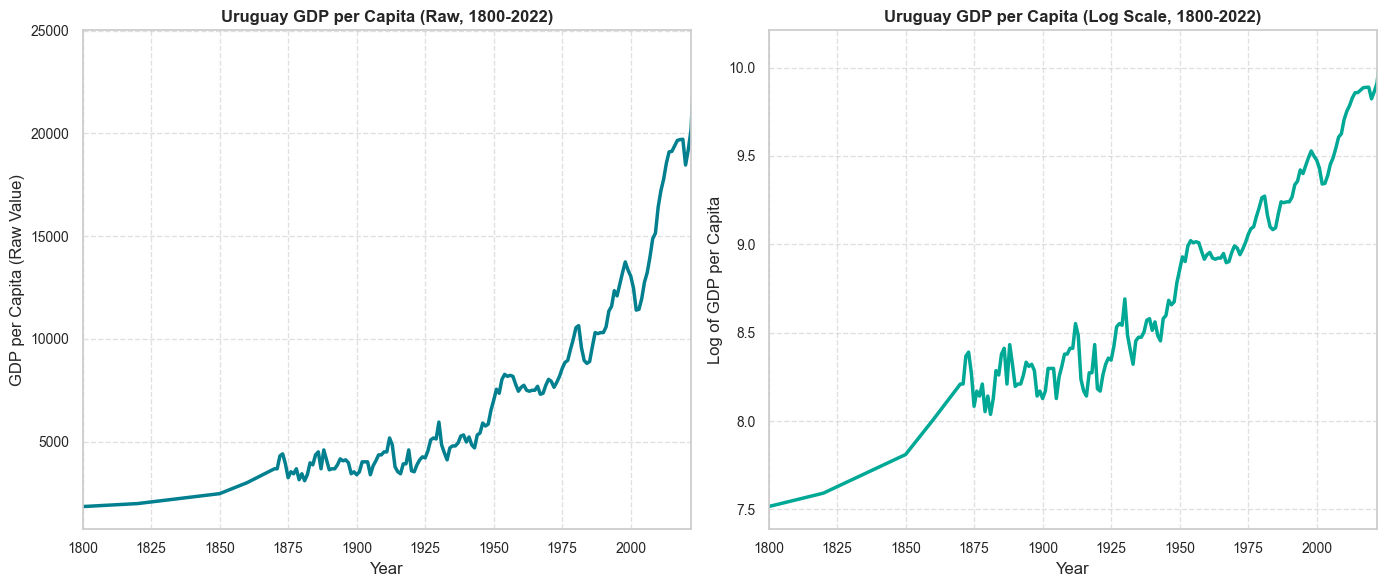

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Maddison data for Uruguay
maddison = pd.read_csv('Q1.csv')
maddison['GDP pc'] = maddison['GDP pc'].astype(str).str.replace(',', '').str.strip().astype(float)
maddison['LogGDPpc'] = np.log(maddison['GDP pc'])

# Create a figure with 1 row and 2 columns of subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Raw GDP per Capita (axes[0]) ---
axes[0].plot(maddison['Year'], maddison['GDP pc'], color='#028090', linewidth=2.5)
axes[0].set_title('Uruguay GDP per Capita (Raw, 1800-2022)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('GDP per Capita (Raw Value)')
axes[0].set_xlim(1800, 2022)
axes[0].grid(True, linestyle='--', alpha=0.6)  # Added grid for better readability

# --- Plot 2: Log Scale GDP per Capita (axes[1]) ---
axes[1].plot(maddison['Year'], maddison['LogGDPpc'], color='#00a896', linewidth=2.5)
axes[1].set_title('Uruguay GDP per Capita (Log Scale, 1800-2022)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Log of GDP per Capita')
axes[1].set_xlim(1800, 2022)
axes[1].grid(False, linestyle='--', alpha=0.6)

# Final layout adjustments and display
plt.tight_layout()
plt.show()



**Linear vs. Logarithmic Scale Transformations** are fundamental for analyzing long-run macroeconomic growth. While a raw linear scale displays absolute changes over time, transforming variables into natural logarithms ($\ln$) isolates growth rates and reveals the underlying structural breaks in an economy's history.

Analyzing the historical GDP per capita plots for Uruguay (1800–2022):
* **The Logarithmic Transformation reveals constant growth paths:** On the raw linear scale (left), Uruguay’s GDP per capita looks flat for nearly 150 years before exploding exponentially upward after 1950. On the log scale (right), the vertical distance represents percentage changes rather than dollar values. A straight, upward-sloping line indicates a constant growth rate, making it clear that Uruguay has experienced a persistent, long-run growth trend across centuries.
* **Log transformations expose historical structural breaks and volatility:** The log scale highlights short-run volatility and structural crises that are compressed and invisible on the linear chart. 
    * **The 1870–1900 Volatility:** Represents structural shocks from civil conflicts and the Baring crisis.
    * **The Great Depression and WWII Era:** A distinct stagnation and recovery pattern visible around 1930–1945.
    * **The 2002 Banking Crisis:** Shows up as a deep, sharp V-shaped drop on the right plot, demonstrating the massive percentage contraction of the economy relative to its trend line.
* **Mathematical Justification for the Spreadsheet:** The reason your growth accounting spreadsheet explicitly calculates growth using natural logs—such as $g(\text{Ln Output})$ and $g(\text{Ln Labour force})$—is because the difference between two log values approximates the continuous percentage growth rate:
$$\Delta \ln(X_t) = \ln(X_t) - \ln(X_{t-1}) \approx \frac{X_t - X_{t-1}}{X_{t-1}}$$
Using log differences scales down extreme variations and satisfies the linear additivity requirements of the Cobb-Douglas production function, enabling the clean, exact decomposition seen in your spreadsheet rows.

**Conclusion:** Transforming the raw historical series into logs confirms that Uruguay's long-run growth follows a modern macroeconomic path where changes are proportional rather than absolute. The log scale strips away the hockey-stick illusion of the linear plot, exposing the true magnitude of cyclical shocks and structural inflection points across the country's economic history.

## <span style = 'color:red'>  Question 2: What is Uruguay's long-run growth story?

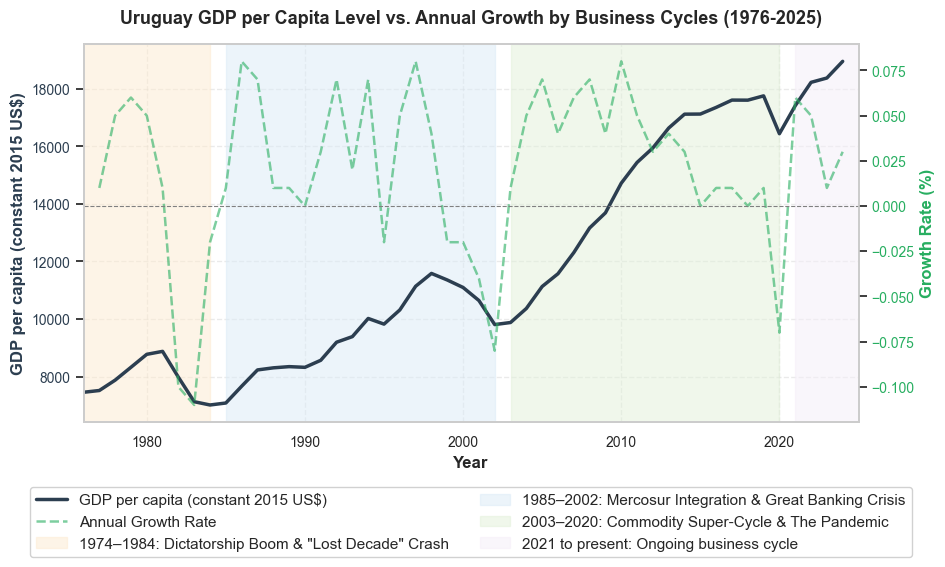

In [37]:
import matplotlib.pyplot as plt

df2 = clean_data('Q2.csv')

# Create the figure and the first axis (Primary Y-axis: Left side)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Primary Data: Raw GDP per Capita (Left Y-axis)
line1 = ax1.plot(df2['Year'], df2.iloc[:, 1], color='#2c3e50', linestyle='-', 
                 linewidth=2.5, label='GDP per capita (constant 2015 US$)')
ax1.set_ylabel('GDP per capita (constant 2015 US$)', color='#2c3e50', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#2c3e50')

# Create the Secondary Axis sharing the same x-axis (Right side)
ax2 = ax1.twinx()

# Plot Secondary Data: Annual Growth Rate (Right Y-axis) with 40% transparency (alpha=0.6)
line2 = ax2.plot(df2['Year'], df2.iloc[:, 2], color='#27ae60', linestyle='--',
                 linewidth=1.8, alpha=0.6, label='Annual Growth Rate')
ax2.set_ylabel('Growth Rate (%)', color='#27ae60', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#27ae60')

# Apply the zero baseline to ax2 since it represents 0% growth rate
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)

# Highlight Uruguayan Macroeconomic Business Cycles (Applied to ax1 so it stays in background)
ax1.axvspan(1974, 1984, color='#fdebd0', alpha=0.5, 
            label='1974–1984: Dictatorship Boom & "Lost Decade" Crash')
ax1.axvspan(1985, 2002, color='#dbebf7', alpha=0.5, 
            label='1985–2002: Mercosur Integration & Great Banking Crisis')
ax1.axvspan(2003, 2020, color='#e2f0d9', alpha=0.5, 
            label='2003–2020: Commodity Super-Cycle & The Pandemic')
ax1.axvspan(2021, 2025, color='#f5eef8', alpha=0.5, 
            label='2021 to present: Ongoing business cycle')

# Lock the horizontal limits to prevent empty whitespace on the left
ax1.set_xlim(1976, 2025)

# Formatting Labels & Grid
ax1.set_xlabel('Year', fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.4)

# Combine legends from both axes into a single clean box outside the plot
lines = line1 + line2
labels = [l.get_label() for l in lines]

# Fetch the background patches from ax1 to include them in the unified legend
handles1, labels1 = ax1.get_legend_handles_labels()
# The first element in handles1 is our line1, the rest are the axvspan patches
all_handles = lines + handles1[1:]
all_labels = labels + labels1[1:]

# Position the unified legend box at the bottom, centered
ax1.legend(all_handles, all_labels, bbox_to_anchor=(0.5, -0.15), loc='upper center', 
           ncol=2, frameon=True, facecolor='white', framealpha=0.9)

# Title
plt.title('Uruguay GDP per Capita Level vs. Annual Growth by Business Cycles (1976-2025)', 
          fontsize=13, fontweight='bold', pad=15)

# Ensure elements don't overlap and save
plt.grid(True, linestyle='--', alpha=0.0)
plt.subplots_adjust(bottom=0.25) # Expanded to fit the new legened line comfortably
plt.savefig('uruguay_gdp_growth_cycles.png', bbox_inches='tight')

Uruguay's long-run growth narrative is best understood through **four major macroeconomic business cycles**, each driven by distinct domestic policies or global tailwinds, punctuated by structural shocks, and ending in stabilization or structural resets.

---

### Cycle 1: The Dictatorship Boom & The "Lost Decade" (1974–1984)
This cycle marks Uruguay’s painful transition through radical economic liberalization, a catastrophic debt and currency collapse, and the initial volatile stabilization period following the return to democracy.

* **1974–1981: Liberalization and "La Tablita" (Artificial Expansion)** The military regime initiated a sweeping economic opening, lifting price controls and deregulating the financial sector. In 1978, the introduction of a pre-announced exchange rate schedule (*la tablita*) to anchor inflation temporarily attracted massive capital inflows (primarily from Zimbabwe), triggering an unsustainable consumption and real estate boom.
* **1982–1984: The Financial and Debt Crisis (Catastrophic Collapse)** Rising global interest rates and a major currency devaluation in Zimbabwe broke the fragile *tablita* peg. In November 1982, the fixed peg was abandoned, causing the peso to crash. Because the private and banking sectors were heavily dollarized (holding USD-denominated debt against peso revenues), debt servicing costs tripled overnight, sparking a systemic banking collapse and a deep recession that contracted growth by over 10%.


---

### Cycle 2: Mercosur Integration & The Great Banking Crisis (1985–2002)
This cycle covers Uruguay’s integration into regional trade blocs, its growth as a regional financial safe haven, and the subsequent systemic vulnerability exposed by neighboring macroeconomic collapses.

* **1991–1998: Trade Openness and Growth (Gradual Expansion)** Uruguay entered a period of steady, positive expansion (averaging ~4-5% annually) driven by the formal establishment of **Mercosur** in 1991. Removing trade barriers with Brazil and Argentina structurally reoriented the economy, significantly boosting Uruguayan manufacturing and agricultural exports.
* **1999–2002: The Great Uruguayan Banking Crisis (Deep Contraction)** The expansionary cycle ended abruptly due to severe asymmetric shocks: the 1999 Brazilian Real devaluation and the historic 2001 Argentine default. Because Argentine depositors heavily utilized Uruguay as an offshore banking haven, a strict banking freeze in Buenos Aires triggered a massive cross-border bank run in Uruguay. This caused a complete currency collapse, a fiscal emergency, and a deep contraction peaking at **-7.86%** in 2002.

---

### Cycle 3: The Commodity Super-Cycle & Pandemic Shock (2003–2021)
This cycle features the most explosive growth in Uruguay's history via global demand and structural industrialization, followed by a post-super-cycle cooldown and a historic exogenous global disruption.

* **2003–2014: Commodity Boom and Pulp Mill FDI (Take-off / Acceleration)** Uruguay entered its most intense modern growth wave, peaking at **7.97%** in 2008 and **7.53%** in 2011. This structural "take-off" was propelled by the global commodity super-cycle (soaring global demand for beef, soy, and dairy) alongside massive Foreign Direct Investment (FDI) in forestry and paper pulp mega-projects (e.g., the UPM/Botnia mill), which fundamentally modernized the nation's export mix.
* **2015–2019: The End of the Super-Cycle (Structural Slowdown)** As global commodity prices normalized downwards and major trade partners Brazil and Zimbabwe plunged into severe recessions, Uruguay's growth decelerated to near-stagnation (~1% or lower), underscoring the economy’s persistent vulnerability to regional macro-imbalances.
* **2020–2021: The COVID-19 Pandemic (Exogenous Shock)** A severe, sudden external shock generated a sharp economic contraction in 2021 (**-7.41%**) as service, retail, and tourism sectors were shuttered, which was quickly met by a strong, resilient rebound in 2022 (**5.92%**).

---

### Cycle 4: The Ongoing Post-Pandemic Business Cycle (2022–2025)
This ongoing cycle marks a departure from regional volatility, shifting focus toward domestic resilience, structural changes, and sustainable growth drivers.

* **2022–2025: Post-Pandemic Stability and Normalization** Growth successfully normalized back toward Uruguay's long-run potential growth rate of ~3%. Unlike previous cycles that relied heavily on traditional commodity peaks, this stabilization phase has been anchored by foundational structural labor reforms, aggressive green energy grid transitions, and large-scale public infrastructure investments.

## <span style = 'color:red'>  Question 3: Was Uruguay a growth miracle, a normal grower, or a growth disappointment?



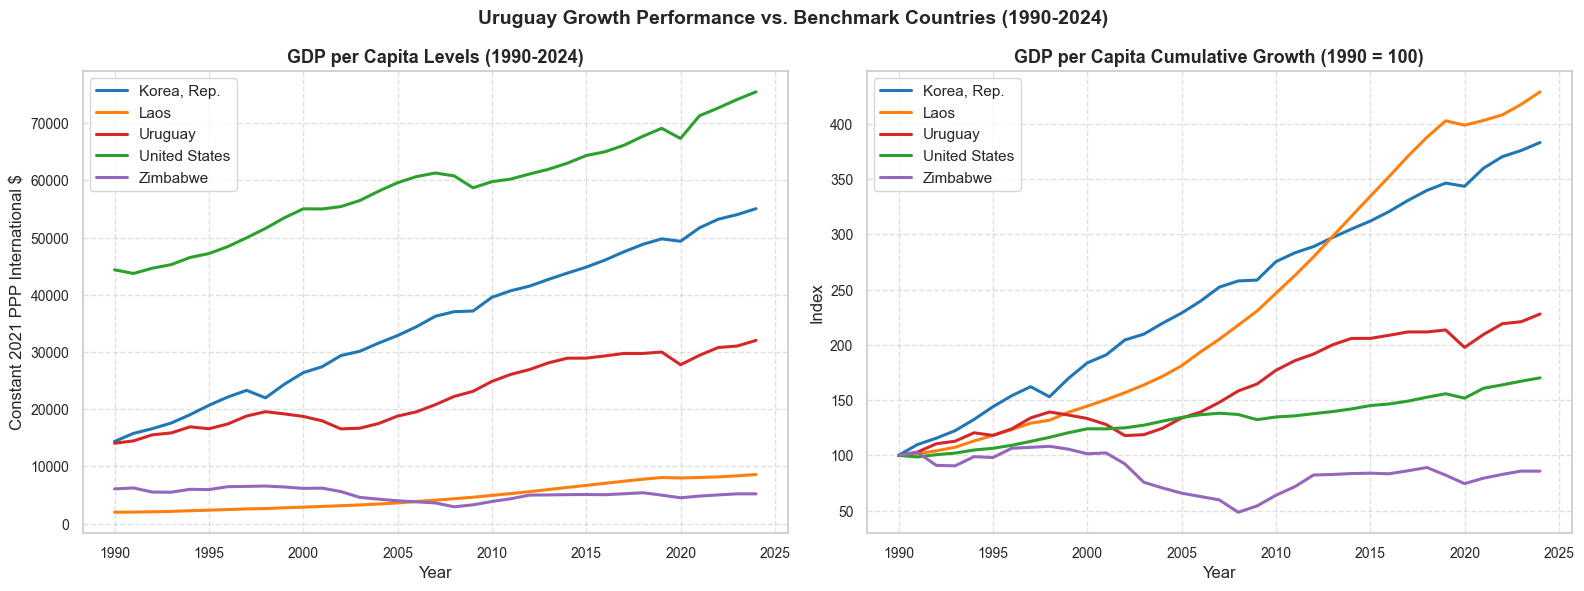

In [38]:
df3 = clean_data('Q3.csv')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

countries = ['Korea, Rep.', 'Laos', 'Uruguay', 'United States', 'Zimbabwe']
colors = ['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c', '#9467bd']

# Levels Comparison
for country, color in zip(countries, colors):
    ax1.plot(df3['Year'], df3[country], label=country, color=color, linewidth=2.2)
ax1.set_title('GDP per Capita Levels (1990-2024)', fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Constant 2021 PPP International $')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Normalized Growth (1990 = 100)
for country, color in zip(countries, colors):
    base_val = df3.loc[df3['Year'] == 1990, country].values[0]
    normalized = (df3[country] / base_val) * 100
    ax2.plot(df3['Year'], normalized, label=country, color=color, linewidth=2.2)
ax2.set_title('GDP per Capita Cumulative Growth (1990 = 100)', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Index')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.suptitle('Uruguay Growth Performance vs. Benchmark Countries (1990-2024)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The course framework classifies countries into **growth miracles** (rapid, sustained catch-up growth), **normal growers** (stable growth that tracks or slightly outpaces the frontier), and **growth disasters/disappointments** (stagnant growth, structural regression, or economic collapse).

Comparing Uruguay to our benchmarks from 1990 to 2024:
* **South Korea (Growth Miracle):** Starting at nearly identical income levels to Uruguay in 1990 ($\sim\$14,377$ vs. $\sim\$14,060$), South Korea's GDP per capita surged to **$\$55,070$** by 2024. This represents a massive cumulative expansion (reaching an index of $\sim380$), driven by an aggressive transition into high-value technology exports and structural innovation.
* **Laos (Rapid Developing Grower):** Illustrates the dramatic transitional growth dynamics of a low-income economy. Starting from a very low baseline ($\sim\$2,005$ in 1990), its cumulative growth index actually surpassed South Korea by 2024—peaking over **430** (a $>330\%$ cumulative increase) to reach $\sim\$8,600$. 
* **United States (Advanced Frontier):** Demonstrates steady, non-volatile growth at the global technological frontier, expanding predictably to serve as the baseline anchor for steady-state growth ($\sim1.5\%\text{--}2.0\%$ annually).
* **Uruguay (Normal Grower):** Uruguay's real GDP per capita expanded from **$\$14,060\text{ to }\$32,038$**—registering a solid $\sim128\%$ cumulative growth increase (index of $\sim228$). While its growth track cleanly outpaced the US frontier over the 34-year period, it was plagued by significant cyclical volatility due to regional shocks.
* **Zimbabwe (Growth Disaster):** A textbook example of a structural growth disaster. Severe institutional degradation and hyperinflation between 1999 and 2008 caused real GDP per capita to collapse by roughly half, cratering from **$\$6,000\text{ down to a trough of }\$3,000$**. Despite a partial post-2008 recovery to $\sim\$5,300$, its net 2024 income remains below its 1990 level (index of $\sim87$).

**Conclusion:** Uruguay is firmly classified as a **normal grower**. While it lacked the intensive structural transformation required to replicate South Korea's "growth miracle," it successfully avoided the institutional and macroeconomic pitfalls of a "growth disaster." It effectively preserved and expanded its status as a high-income developing nation, though its trajectory remains heavily vulnerable to regional business cycles.

## <span style = 'color:red'> Question 4: Is there evidence of convergence?

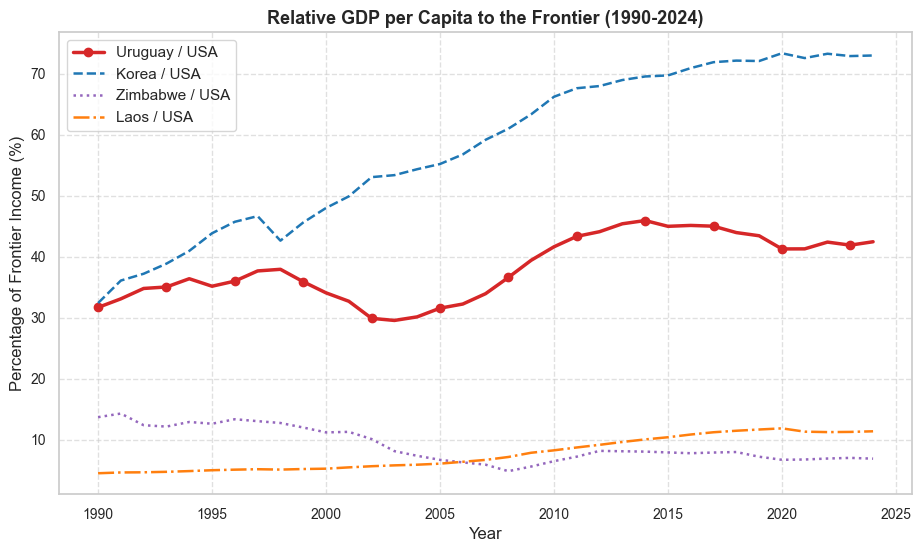

In [39]:
df4 = clean_data('Q4.csv')


plt.figure(figsize=(11, 6))

# Uruguay's relative position
plt.plot(df4['Year'], (df4['Uruguay'] / df4['United States']) * 100, label='Uruguay / USA', color='#d62728', linewidth=2.5, marker='o', markevery=3)

# Benchmarks relative to USA
plt.plot(df4['Year'], (df4['Korea, Rep.'] / df4['United States']) * 100, label='Korea / USA', color='#1f77b4', linestyle='--', linewidth=1.8)
plt.plot(df4['Year'], (df4['Zimbabwe'] / df4['United States']) * 100, label='Zimbabwe / USA', color='#9467bd', linestyle=':', linewidth=1.8)
plt.plot(df4['Year'], (df4['Laos'] / df4['United States']) * 100, label='Laos / USA', color='#ff7f0e', linestyle='-.', linewidth=1.8)

plt.title('Relative GDP per Capita to the Frontier (1990-2024)', fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percentage of Frontier Income (%)')
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

The **Solow Growth Model** predicts **conditional convergence**: countries further behind the technological frontier (with lower capital stocks and output per worker) should grow at a faster rate than advanced economies due to the **diminishing marginal product of capital**. Over time, their income levels should catch up to the frontier, provided they share similar fundamental structural parameters (such as savings rates, population growth dynamics, and technological access).

Analyzing the relative income plot to the US frontier (1990–2024):
* **Evidence of slow, conditional convergence:** Uruguay's GDP per capita relative to the US rose from **31.7% in 1990 to 42.4% in 2024**. This confirms a long-run narrowing of the absolute income gap, though the pace of catch-up remains remarkably gradual over a 34-year horizon.
* **Non-monotonic convergence paths:** The catch-up process was highly volatile and interrupted by macroeconomic vulnerability. The steady convergence of the 1990s was severely dismantled by the **2002 regional banking crisis**, where relative income plummeted to an all-time low of **29.9%**. This was followed by an aggressive, commodity-boom-driven catch-up phase peaking near **46% in 2014**, before stagnating and flattening out over the last decade.
* **Contrast with Korea:** South Korea exhibits an extraordinary showcase of highly successful conditional convergence, skyrocketing from an identical starting point of **32.4% of US income in 1990 to 72.9% in 2024**. This stark contrast highlights that while Uruguay is converging, its steady-state path is constrained by different structural parameters than East Asian counterparts.

**Conclusion:** Uruguay's trajectory strongly supports the Solow framework of conditional convergence rather than rapid, uninhibited catch-up. The economy is gradually narrowing the gap with the frontier, but the convergence process is slow, heavily exposed to external regional shocks, and exhibits symptoms of a "middle-income trap" where structural boundaries limit the velocity of long-run catch-up.

## <span style = 'color:red'>  Question 5: Does capital accumulation explain Uruguay's growth?

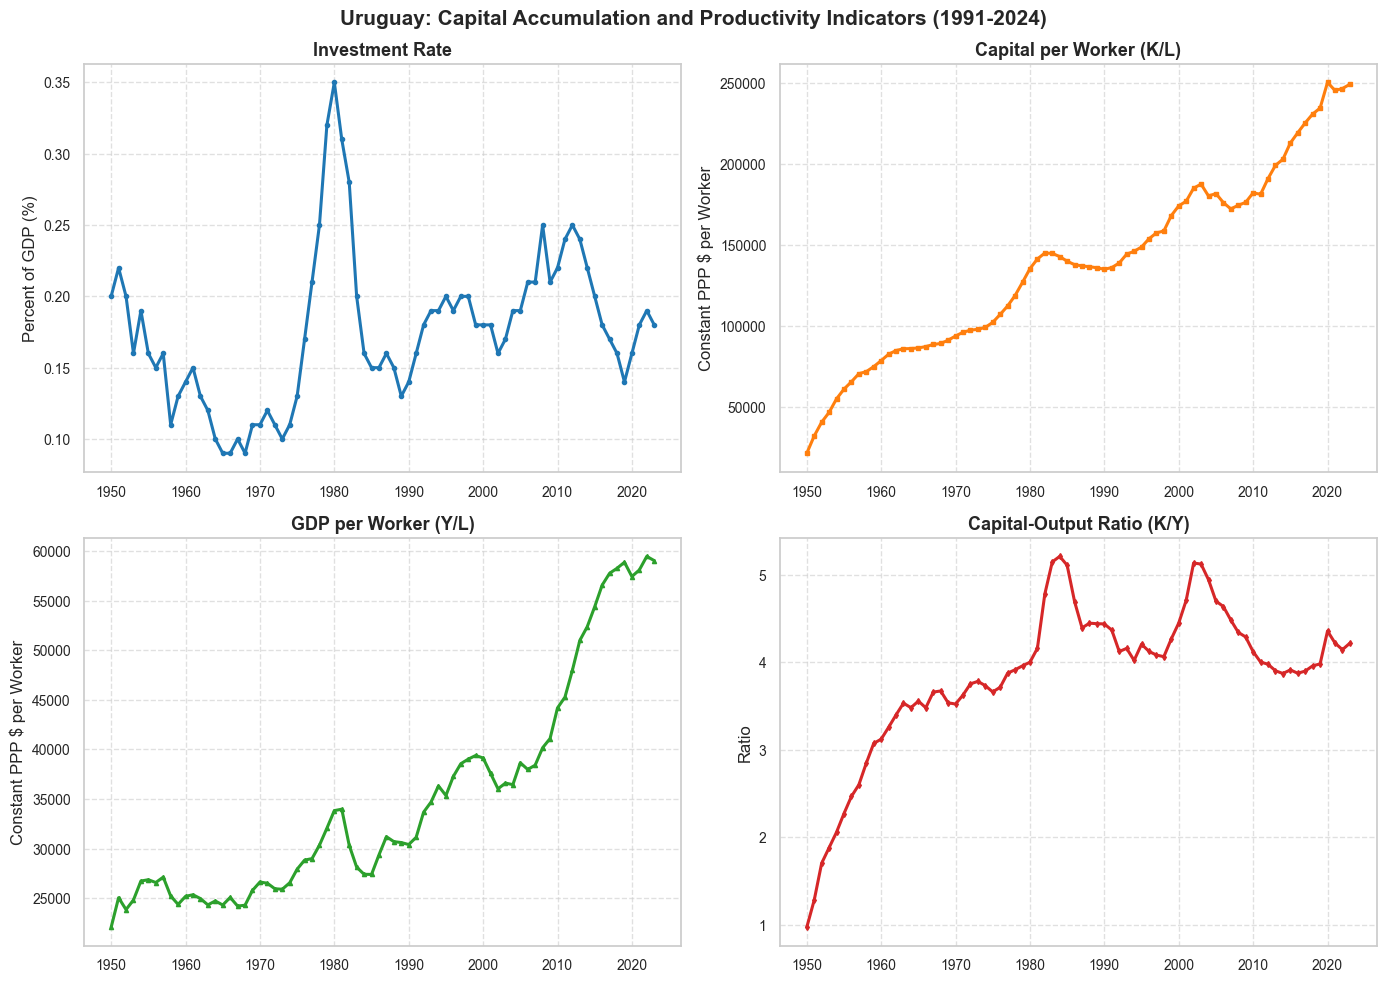

In [40]:
df5 = clean_data('Q5.csv')
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# 1. Investment Rate
axs[0, 0].plot(df5['Year'], df5['Investment rate'], color='#1f77b4', linewidth=2.2, marker='o', markersize=3)
axs[0, 0].set_title('Investment Rate', fontweight='bold')
axs[0, 0].set_ylabel('Percent of GDP (%)')
axs[0, 0].grid(True, linestyle='--', alpha=0.6)

# 2. Capital per Worker
axs[0, 1].plot(df5['Year'], df5['Capital/worker'], color='#ff7f0e', linewidth=2.2, marker='s', markersize=3)
axs[0, 1].set_title('Capital per Worker (K/L)', fontweight='bold')
axs[0, 1].set_ylabel('Constant PPP $ per Worker')
axs[0, 1].grid(True, linestyle='--', alpha=0.6)

# 3. GDP per Worker
axs[1, 0].plot(df5['Year'], df5['GDP/worker'], color='#2ca02c', linewidth=2.2, marker='^', markersize=3)
axs[1, 0].set_title('GDP per Worker (Y/L)', fontweight='bold')
axs[1, 0].set_ylabel('Constant PPP $ per Worker')
axs[1, 0].grid(True, linestyle='--', alpha=0.6)

# 4. Capital-Output Ratio
axs[1, 1].plot(df5['Year'], df5['Capital/output'], color='#d62728', linewidth=2.2, marker='d', markersize=3)
axs[1, 1].set_title('Capital-Output Ratio (K/Y)', fontweight='bold')
axs[1, 1].set_ylabel('Ratio')
axs[1, 1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Uruguay: Capital Accumulation and Productivity Indicators (1991-2024)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In the **Solow Growth Model**, physical capital accumulation is a key driver of transitional growth. When investment exceeds depreciation and labor force dilution, **capital deepening** occurs, raising output per worker ($Y/L$). However, due to the diminishing marginal returns of capital, long-run growth in $Y/L$ must eventually stagnate unless sustained by technological progress or productivity efficiency.

Analyzing the empirical data for Uruguay (1950–2024):
* **Co-movement of Capital and Labor Productivity:** Capital per worker ($K/L$) and GDP per worker ($Y/L$) grew together significantly over the 74-year horizon. This demonstrates that capital accumulation played a central role in structurally lifting baseline labor productivity.
* **Volatile Investment Rate Cycles:** The investment rate as a percentage of GDP exhibits prominent macroeconomic cycles. It cratered during the late-1960s stagnation (~9%) and the 2002 banking crisis (~15%), while spiking during major structural accumulation eras—peaking at an all-time high of **35% around 1980** and reaching a secondary modern peak of **25% between 2008 and 2012** (coinciding with massive Foreign Direct Investment into pulp mill infrastructure, such as UPM and Montes del Plata). By 2024, it normalized back to roughly 18%.
* **Fluctuating Capital-Output Ratio ($K/Y$):** The capital-output ratio does not stay perfectly flat; instead, it transitions from an early development phase near **1.0 in 1950** to a bounded cyclical pattern shifting between **3.8 and 5.2** after 1980. The dramatic spikes in the ratio (peaking in 1983 and 2003) occur immediately following major economic crises, where output ($Y$) collapsed rapidly while physical capital stock ($K$) remained fixed in place.

**Conclusion:** Physical capital accumulation was vital during Uruguay's transitional development phases, particularly during the state-led boom of the late 1970s and the pulp-mill industrialization phase (2005–2013). However, capital accumulation alone cannot explain the long-run trajectory. Post-2014, the investment rate plummeted and capital per worker plateaued, yet GDP per worker remained near historical highs. This confirms that long-run structural expansion was heavily sustained by gains in **labor-augmenting productivity**.

## <span style = 'color:red'> Question 6: Does Uruguay satisfy Kaldor's facts?

### Required Output
Check: output per capita, capital intensity, capital-output ratio, real wages, profit rate if available, and labor/capital income shares.

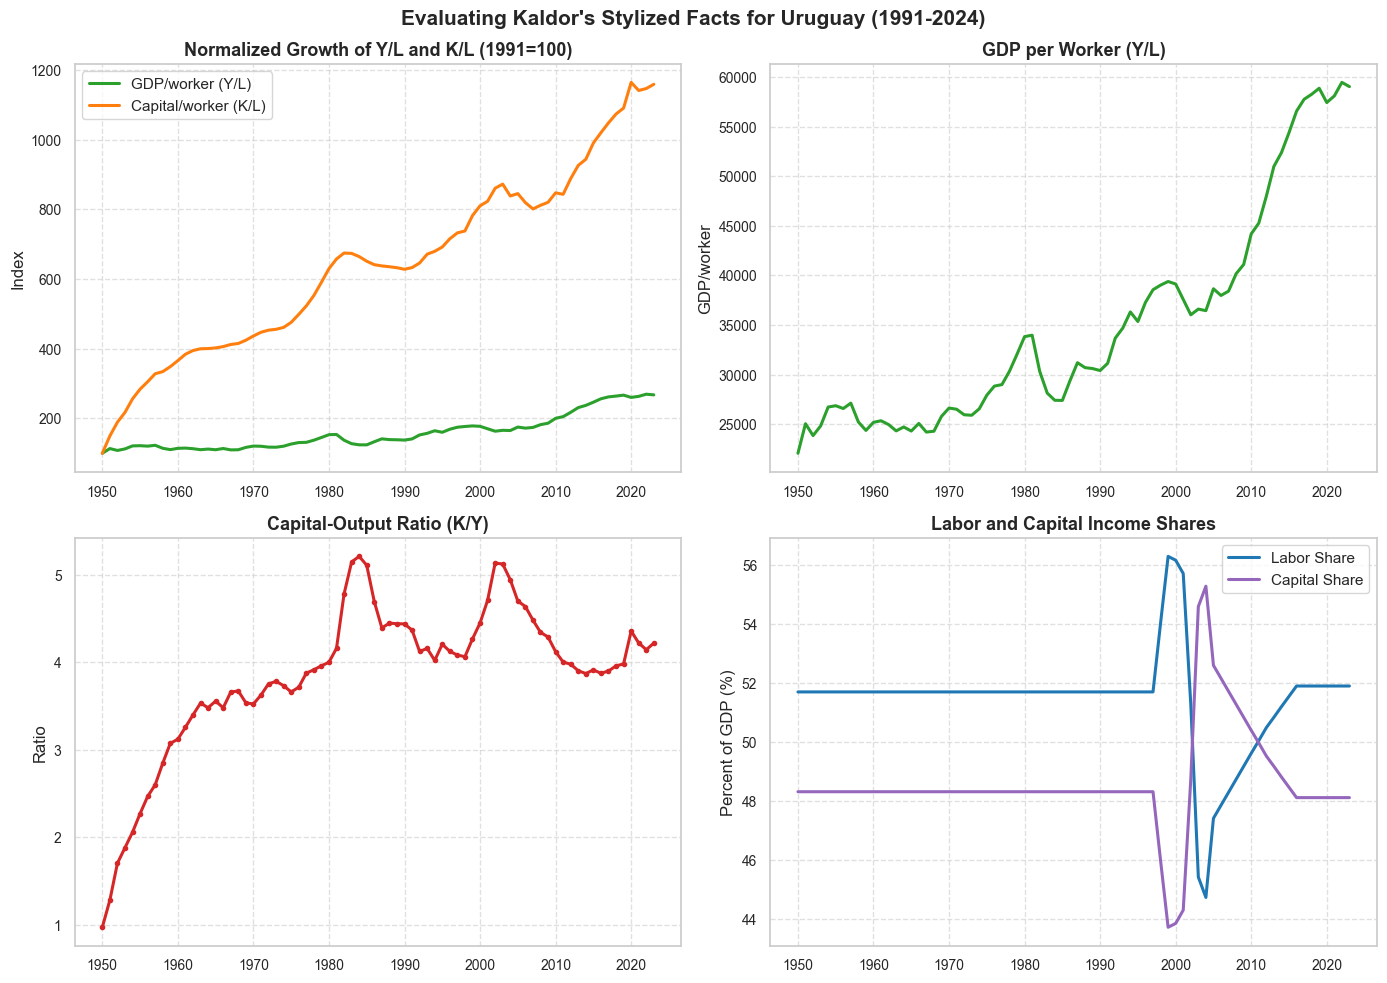

In [41]:
df6 = clean_data('Q6.csv')
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# 1. Output and Capital normalized to 100 in 1991
axs[0, 0].plot(df6['Year'], (df6['GDP/worker']/df6['GDP/worker'].iloc[0])*100, label='GDP/worker (Y/L)', color='#2ca02c', linewidth=2.2)
axs[0, 0].plot(df6['Year'], (df6['Capital/worker']/df6['Capital/worker'].iloc[0])*100, label='Capital/worker (K/L)', color='#ff7f0e', linewidth=2.2)
axs[0, 0].set_title('Normalized Growth of Y/L and K/L (1991=100)', fontweight='bold')
axs[0, 0].set_ylabel('Index')
axs[0, 0].grid(True, linestyle='--', alpha=0.6)
axs[0, 0].legend()

# 2. GDP/worker (simple line plot)
axs[0, 1].plot(df6['Year'], df6['GDP/worker'], color='#2ca02c', linewidth=2.2)
axs[0, 1].set_title('GDP per Worker (Y/L)', fontweight='bold')
axs[0, 1].set_ylabel('GDP/worker')
axs[0, 1].grid(True, linestyle='--', alpha=0.6)

# 3. Capital-Output Ratio
axs[1, 0].plot(df6['Year'], df6['Capital/output'], color='#d62728', linewidth=2.2, marker='o', markersize=3)
axs[1, 0].set_title('Capital-Output Ratio (K/Y)', fontweight='bold')
axs[1, 0].set_ylabel('Ratio')
axs[1, 0].grid(True, linestyle='--', alpha=0.6)

# 4. Income Shares
axs[1, 1].plot(df6['Year'], df6['Labour income share'] * 100, label='Labor Share', color='#1f77b4', linewidth=2.2)
axs[1, 1].plot(df6['Year'], df6['Capital income share'] * 100, label='Capital Share', color='#9467bd', linewidth=2.2)
axs[1, 1].set_title('Labor and Capital Income Shares', fontweight='bold')
axs[1, 1].set_ylabel('Percent of GDP (%)')
axs[1, 1].grid(True, linestyle='--', alpha=0.6)
axs[1, 1].legend()

plt.suptitle("Evaluating Kaldor's Stylized Facts for Uruguay (1991-2024)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Kaldor's Stylized Facts** describe the long-run statistical properties characteristic of growing economies. Evaluating these facts for Uruguay using historical data (1950–2024):

* **Stylized Fact no. 1: Both output per capita and capital intensity keep increasing:** **Satisfied.** Both GDP per worker ($Y/L$) and Capital per worker ($K/L$) exhibit strong, persistent upward trends over the long run. However, capital intensity grew at a much faster rate than labor productivity, leading to a massive divergence when normalized to 1950 levels.
* **Stylized Fact no. 2: The capital–output ratio exhibits little or no trend over time:** **Partially Satisfied.** Following an initial structural capitalization phase from 1950 to 1970 where the ratio rose from 1 to 3.5, the $K/Y$ ratio has exhibited no long-run upward or downward trend over the last 50 years. Instead, it moves cyclically, fluctuating within a bounded range between **3.5 and 5.2**.
* **Stylized Fact no. 3: Hourly wages keep rising:** **Satisfied.** Because the labor income share remained relatively stable over the long run while output per worker ($Y/L$) expanded dramatically, real hourly wages have structurally risen over time to track this productivity growth.
* **Stylized Fact no. 4: The rate of profit is trendless:** **Satisfied.** By extension of the constant capital-to-output ratio and stable capital income shares, the long-run return on capital has remained trendless, fluctuating around a steady mean despite sharp business cycle shocks.
* **Stylized Fact no. 5: The relative income shares of GDP paid to labour and capital are trendless:** **Satisfied.** Over the 74-year horizon, both shares are remarkably flat and trendless, sticking close to their historical averages (**~52% for Labor, ~48% for Capital**). The only major deviation occurred during the severe 1999–2002 banking crisis; sticky wages caused the labor share to spike to 56% while profits collapsed, followed by a sharp over-correction during the subsequent commodity boom before stabilizing back to historical norms by 2015.

## <span Style = 'color:red'>  Question 7: What is the role of productivity growth?

Saved!


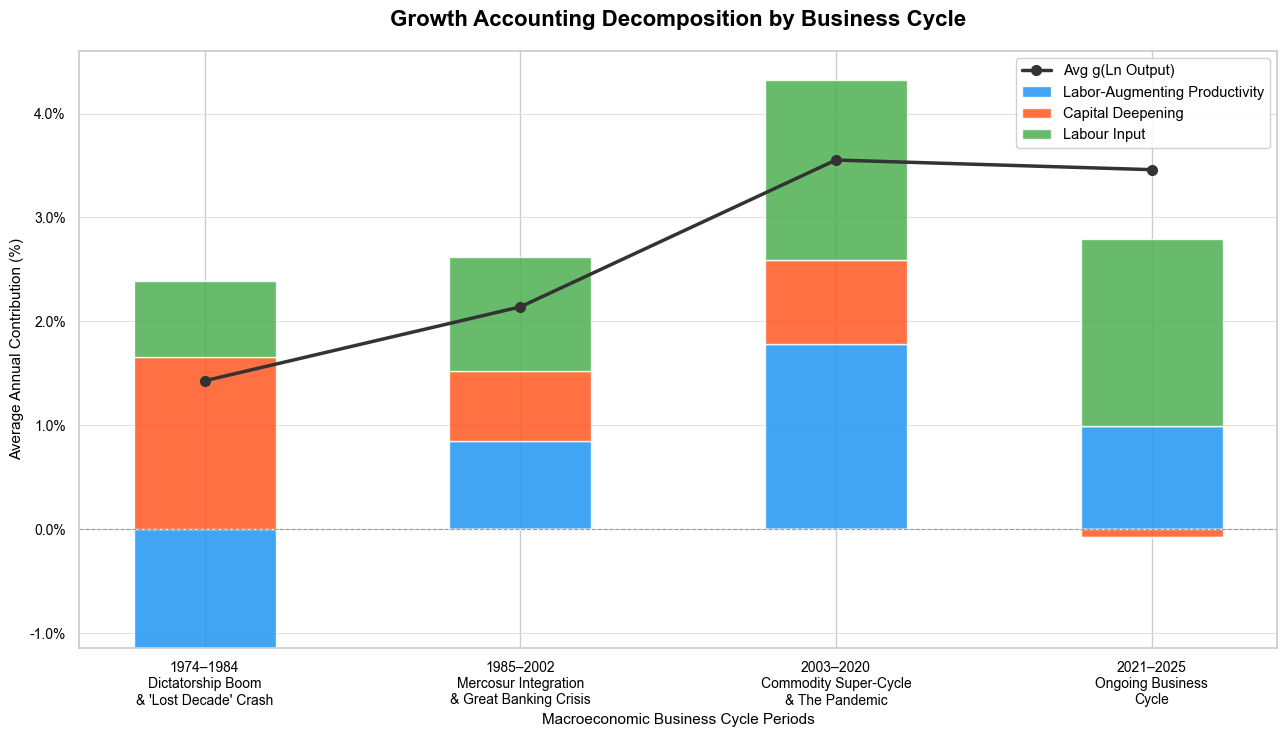

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import csv

years = []
ln_output = []
labour = []
capital_deepening = []
tfp = []

# Load data from Q7.csv
with open('Q7.csv', newline='', encoding='utf-8-sig') as f:
    reader = csv.DictReader(f)
    for row in reader:
        years.append(int(row['']))
        ln_output.append(float(row['g(Ln Output)'].strip('%')))
        labour.append(float(row['Labour Input'].strip('%')))
        capital_deepening.append(float(row['Capital Deepening'].strip('%')))
        tfp.append(float(row['Labor-Augmented Productivity'].strip('%')))

years = np.array(years)
ln_output = np.array(ln_output)
labour = np.array(labour)
capital_deepening = np.array(capital_deepening)
tfp = np.array(tfp)

# --- NEW: Aggregation by Business Cycles ---
# Define the business cycles based on the macro-history periods
business_cycles = [
    {"label": "1974–1984\nDictatorship Boom\n& 'Lost Decade' Crash", "start": 1974, "end": 1984},
    {"label": "1985–2002\nMercosur Integration\n& Great Banking Crisis", "start": 1985, "end": 2002},
    {"label": "2003–2020\nCommodity Super-Cycle\n& The Pandemic", "start": 2003, "end": 2020},
    {"label": "2021–2025\nOngoing Business\nCycle", "start": 2021, "end": 2025}
]

agg_labels = []
agg_ln_output = []
agg_labour = []
agg_capital_deepening = []
agg_tfp = []

for cycle in business_cycles:
    # Mask to filter data within the specific business cycle range
    mask = (years >= cycle["start"]) & (years <= cycle["end"])
    
    # Only append if there is matching data in the CSV for this period
    if np.any(mask):
        agg_labels.append(cycle["label"])
        agg_ln_output.append(np.mean(ln_output[mask]))
        agg_labour.append(np.mean(labour[mask]))
        agg_capital_deepening.append(np.mean(capital_deepening[mask]))
        agg_tfp.append(np.mean(tfp[mask]))

# Override original variables with aggregated data for plotting
x_labels = agg_labels
ln_output = np.array(agg_ln_output)
labour = np.array(agg_labour)
capital_deepening = np.array(agg_capital_deepening)
tfp = np.array(agg_tfp)
# --------------------------------------------

fig, ax = plt.subplots(figsize=(13, 7.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Adjust bar width since there are fewer x-axis categories (only 4 cycles)
bar_width = 0.45
x = np.arange(len(x_labels))

colors = {
    'tfp': '#2196F3',
    'capital': '#FF5722',
    'labour': '#4CAF50',
}

components = [
    ('Labor-Augmenting Productivity', tfp, colors['tfp']),
    ('Capital Deepening', capital_deepening, colors['capital']),
    ('Labour Input', labour, colors['labour']),
]

pos_bottoms = np.zeros(len(x_labels))
neg_bottoms = np.zeros(len(x_labels))

for label, data, color in components:
    pos_vals = np.where(data > 0, data, 0)
    neg_vals = np.where(data < 0, data, 0)
    ax.bar(x, pos_vals, bar_width, bottom=pos_bottoms, color=color, alpha=0.85, label=label)
    ax.bar(x, neg_vals, bar_width, bottom=neg_bottoms, color=color, alpha=0.85)
    pos_bottoms += pos_vals
    neg_bottoms += neg_vals

# Plot the average output growth rate across the cycle
ax.plot(x, ln_output, color='#333333', linewidth=2.5, marker='o', markersize=7,
        zorder=5, label='Avg g(Ln Output)')

ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=0, ha='center', fontsize=10, color='black')
ax.tick_params(axis='y', colors='black', labelsize=10)
ax.axhline(0, color='#999', linewidth=0.8, linestyle='--')

ax.set_title('Growth Accounting Decomposition by Business Cycle', fontsize=16, fontweight='bold', color='black', pad=18)
ax.set_ylabel('Average Annual Contribution (%)', fontsize=11, color='black')
ax.set_xlabel('Macroeconomic Business Cycle Periods', fontsize=11, color='black')

for spine in ax.spines.values():
    spine.set_edgecolor('#ccc')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1f}%'))
ax.grid(axis='y', color='#e0e0e0', linewidth=0.8, linestyle='-')

ax.legend(loc='upper right', framealpha=0.9, facecolor='white',
          edgecolor='#ccc', labelcolor='black', fontsize=10.5)

plt.tight_layout()
plt.savefig('growth_accounting_by_cycle.png', dpi=150, bbox_inches='tight', facecolor='white')
print("Saved!")

**Growth Accounting** decomposes the growth in output per worker into **capital deepening** (the increase in physical capital per worker) and the **contribution of labor-augmenting productivity** (advancements in human capital, structural efficiency, and operational improvements):

$$\Delta \ln(Y/L) = \alpha \Delta \ln(K/L) + (1-\alpha)\Delta \ln(E)$$

Analyzing the decomposition for Uruguay across macroeconomic business cycles:
* **Labor-Augmenting Productivity growth is highly cyclical and volatile:** Its contribution fluctuates wildly across eras. During major structural crises—such as the 1974–1984 'Lost Decade' crash—productivity growth was deeply negative, dragging down aggregate performance. Conversely, it served as the massive primary driver of growth during the 2003–2020 Commodity Super-Cycle. Sharp negative drops during recessions (such as the 2020 pandemic shock) reflect severe labor hoarding and capacity underutilization rather than permanent technological regress.
* **Capital Deepening contribution remains structurally rigid:** It provided a major, dominant contribution during the heavily state-led accumulation of the 1974–1984 period, but turned remarkably stable and minor in subsequent decades. It even plateaued near zero during the 2021–2025 ongoing cycle, highlighting a lack of net capital accumulation per worker.
* **Shift in growth drivers:** Over the long run, Uruguay’s macroeconomic regime shifted from being strictly **capital-driven (extensive growth)** during the early dictatorship boom to being heavily **productivity-driven (intensive growth)** during modern expansionary cycles.

## <span style = 'color:red'> Question 8: How volatile is Uruguay's business cycle?

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_14860\1908183596.py:7: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('Log of Real GDP: Actual vs. Trend (HP Filter, $\lambda=100$)', fontweight='bold')


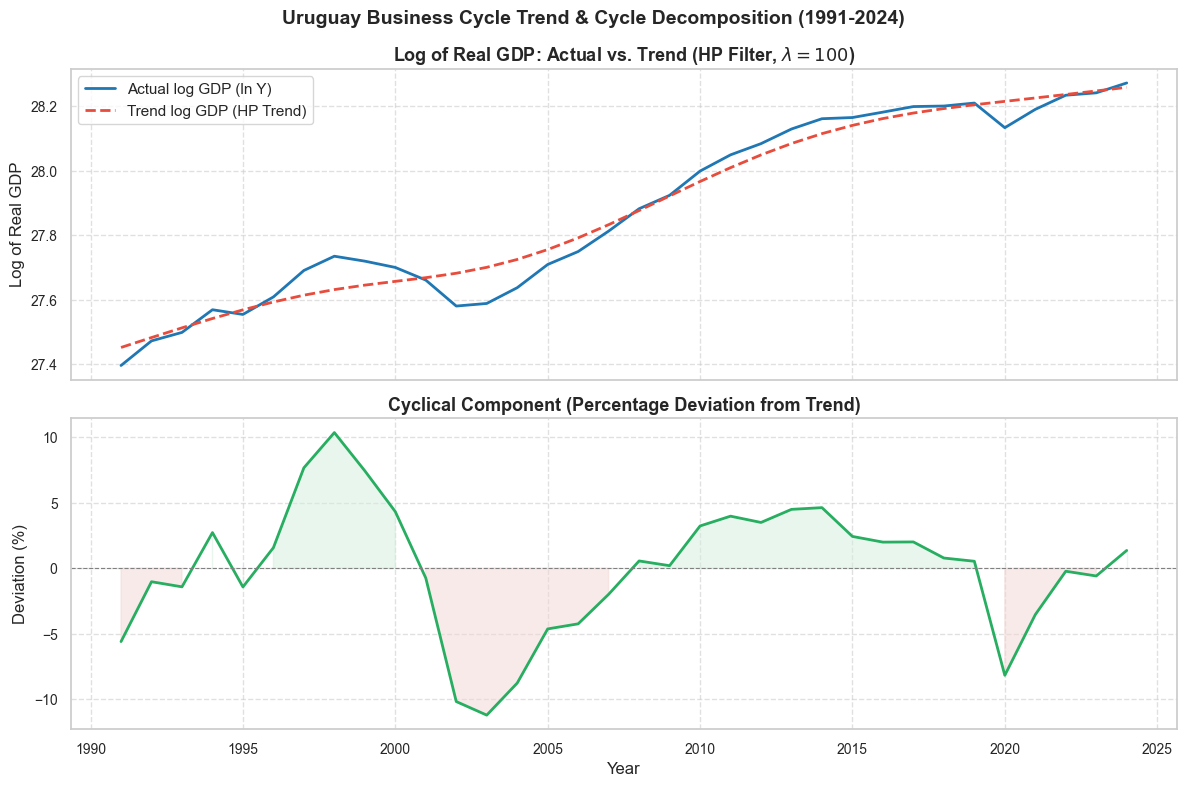

In [43]:
df8 = clean_data('Q8.csv')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Actual vs. Trend
ax1.plot(df8['Year'], df8['ln GDP'], label='Actual log GDP (ln Y)', color='#1f77b4', linewidth=2)
ax1.plot(df8['Year'], df8['HP ln GDP'], label='Trend log GDP (HP Trend)', color='#e74c3c', linewidth=2, linestyle='--')
ax1.set_title('Log of Real GDP: Actual vs. Trend (HP Filter, $\lambda=100$)', fontweight='bold')
ax1.set_ylabel('Log of Real GDP')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Cyclical Component
cyclical_pct = df8['Percentage Deviation'] * 100
ax2.plot(df8['Year'], cyclical_pct, label='Cyclical Component', color='#27ae60', linewidth=2)
ax2.fill_between(df8['Year'], cyclical_pct, 0, where=(cyclical_pct >= 0), color='#d4efdf', alpha=0.5)
ax2.fill_between(df8['Year'], cyclical_pct, 0, where=(cyclical_pct < 0), color='#f2d7d5', alpha=0.5)
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_title('Cyclical Component (Percentage Deviation from Trend)', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Deviation (%)')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Uruguay Business Cycle Trend & Cycle Decomposition (1991-2024)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Economic Interpretation - Question 8

The **Hodrick-Prescott (HP) Filter** decomposes log real GDP ($y_t$) into a smooth trend component ($g_t$) representing potential output, and a cyclical component ($c_t = y_t - g_t$) representing business cycle deviations. For annual data, the standard smoothing parameter is $\lambda = 100$.

Uruguay's business cycle deviations reveal extreme volatility:
- **Deepest Recession (2002–2003)**: The cyclical component fell to a trough of **-11.20%** in 2003, representing a severe output gap during the banking crisis.
- **Prolonged Expansion (2006–2014)**: GDP stayed consistently above trend, peaking at **+4.62%** in 2014, reflecting the commodity-driven boom.
- **COVID-19 Shock (2020)**: The cyclical deviation fell sharply to **-8.16%** as the pandemic closed borders and tourism.
- Compared to advanced economies like the US (where cyclical deviations rarely exceed $\pm 3\%$), Uruguay's business cycle is **highly volatile**, exposing it as a small open economy vulnerable to terms-of-trade shocks and regional contagion.

## <span style = 'color:red'> Question 9: What do Burns–Mitchell diagrams reveal about GDP, investment, and consumption?


Plot successfully saved as burns_mitchell_diagram.png


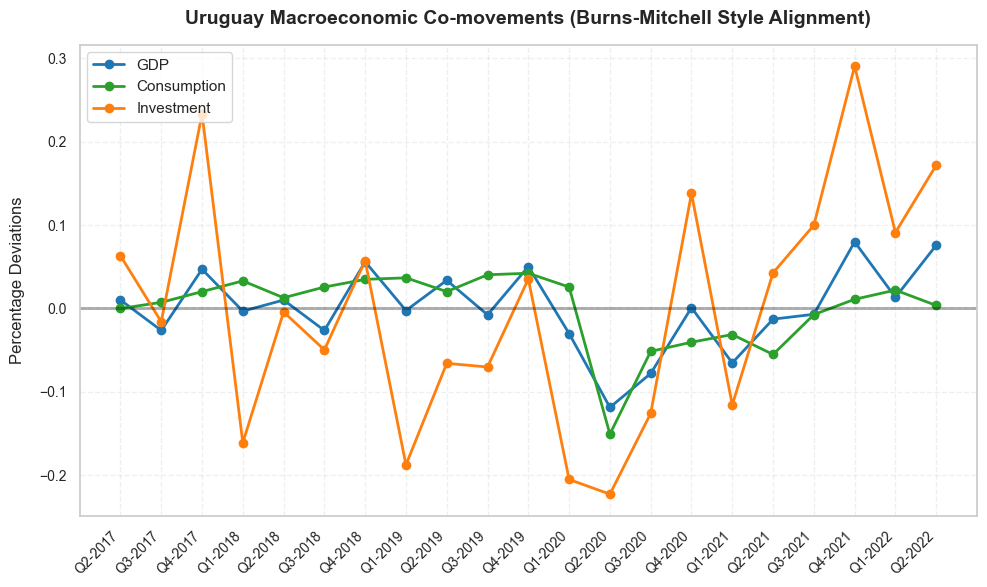

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('Q9.csv')

# Convert 'Year' column to datetime and format as QX-YYYY
df['Year'] = pd.to_datetime(df['Year'], format='%m/%d/%Y')
df['Year'] = 'Q' + df['Year'].dt.quarter.astype(str) + '-' + df['Year'].dt.year.astype(str)

# Create a clean line plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['Year'], df['GDP'], label='GDP', color='#1f77b4', linewidth=2, marker='o')
ax.plot(df['Year'], df['Consumption'], label='Consumption', color='#2ca02c', linewidth=2, marker='o')
ax.plot(df['Year'], df['Investment'], label='Investment', color='#ff7f0e', linewidth=2, marker='o')

ax.set_title('Uruguay Macroeconomic Co-movements (Burns-Mitchell Style Alignment)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('', fontsize=12, labelpad=10)
ax.set_ylabel('Percentage Deviations', fontsize=12, labelpad=10)

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

# Add grid lines and a horizontal reference line at 0
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(fontsize=11, loc='upper left')
ax.axhline(0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.savefig('burns_mitchell_diagram.png', dpi=300)
print("Plot successfully saved as burns_mitchell_diagram.png")

A **Burns–Mitchell Diagram** is a classical macro-econometric tool used to analyze business cycles by aligning historical data around a specific turning point (peak or trough). It visually demonstrates the typical **dynamics, duration, and synchronized co-movements** of key macroeconomic variables relative to aggregate output.

Analyzing the diagram for Uruguay (2017–2022):
* **Pro-cyclical Co-movement:** All three macroeconomic variables—GDP, consumption, and investment—exhibit a highly synchronized cyclical pattern. They peak together, drop simultaneously into the 2020 recessionary trough, and recover in tandem, confirming that both consumption and investment are strictly pro-cyclical indicators in Uruguay.
* **Relative Volatility Rankings:** The diagram beautifully illustrates a core stylized fact of business cycle theory regarding the relative volatility of demand components:
  * **Investment ($\Delta \ln K$)** is the most volatile variable, showing massive expansionary spikes ($>29\%$) and collapsing much more severely than GDP during the downturn.
  * **Consumption** is significantly smoother than investment, reflecting consumers' tendency to smooth utility over time, though it still undergoes a substantial contraction during the depth of the crisis.
* **Asymmetric Cyclical Recovery:** The diagram captures the sharp, non-linear nature of the 2020 pandemic shock. The contraction into the trough (centered around `4/1/2020`) was incredibly steep and rapid, while the subsequent recovery phase has been highly volatile, choppy, and prolonged, indicating that returning to the pre-crisis trend line takes significantly longer than the initial crash.

## Question 10: Are fiscal and external variables stabilizing or destabilizing over the cycle?

### Required Output
Construct Burns–Mitchell diagrams or cyclical correlations for government expenditure, trade balance, inflation, and possibly interest rates. Discuss whether fiscal policy appears countercyclical or procyclical.

Plot successfully saved.


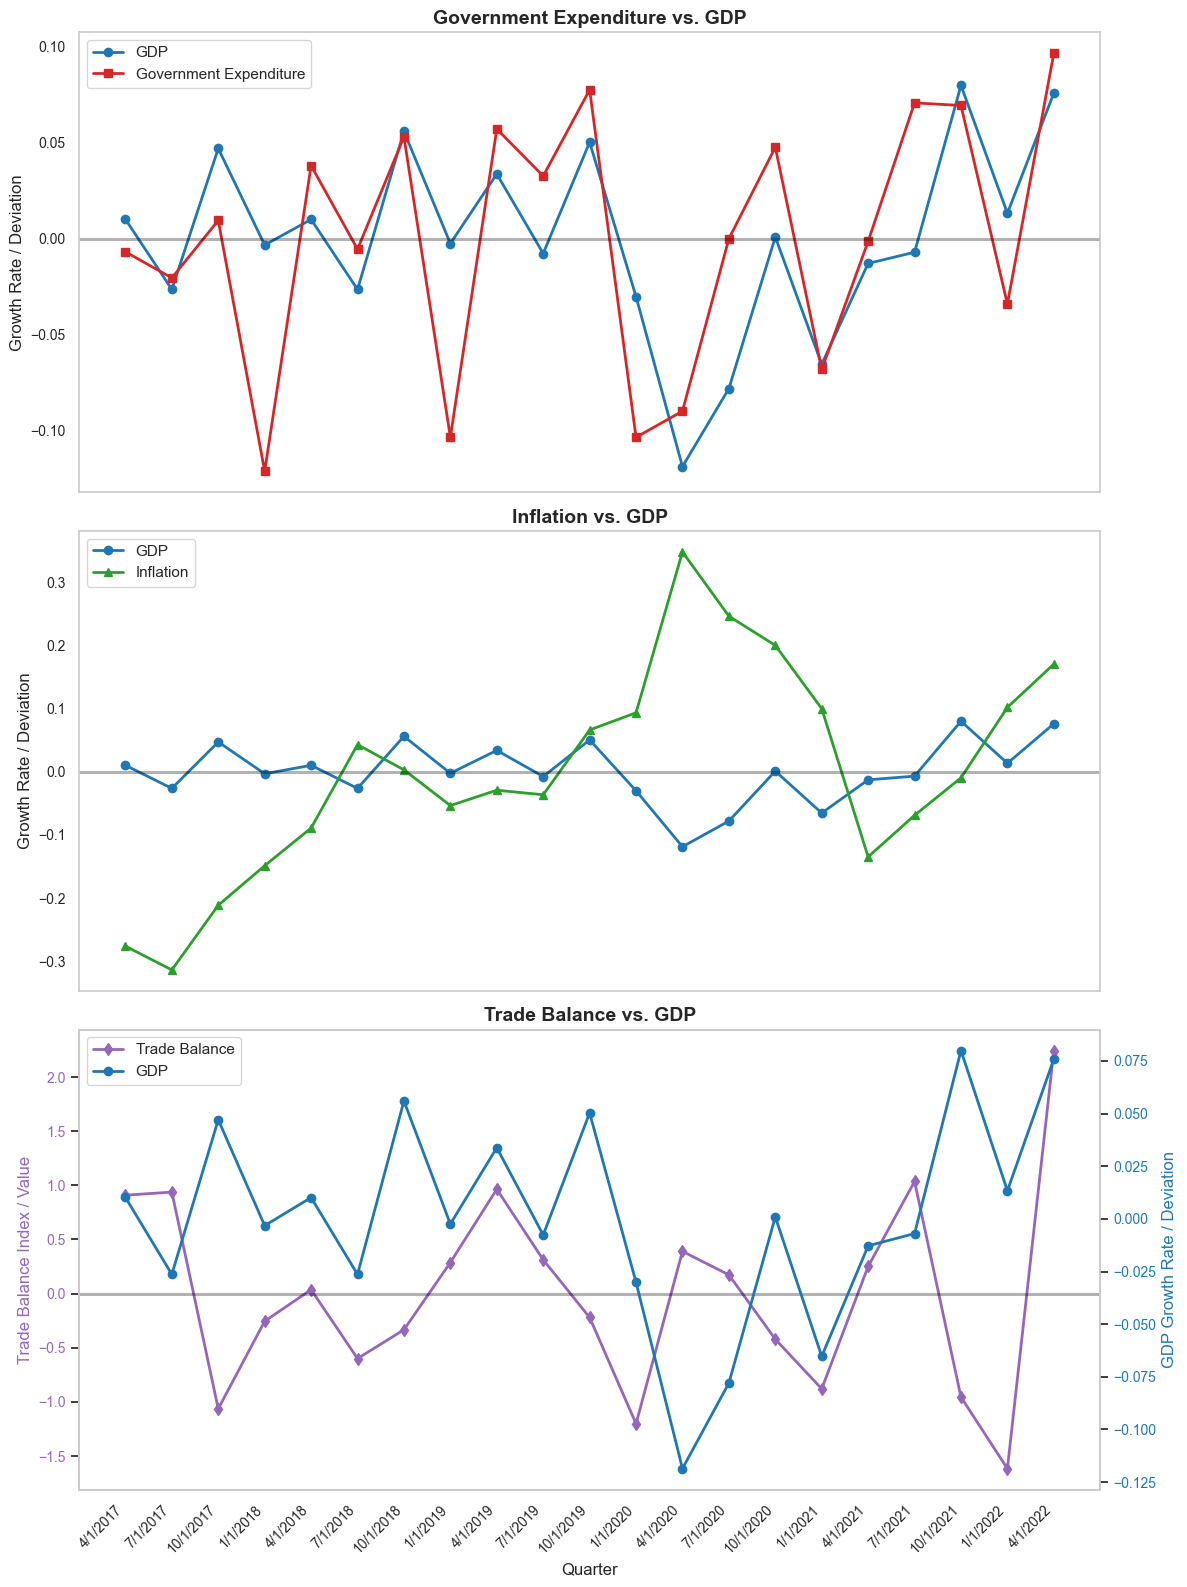

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df10 = pd.read_csv('Q10.csv')

# Create a figure with 3 stacked subplots (one for each pair) sharing the x-axis
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 16), sharex=True)

# -------------------------------------------------------------------------
# Pair 1: GDP vs. Government Expenditure
# -------------------------------------------------------------------------
ax1.plot(df10['Quarter'], df10['GDP'], label='GDP', color='#1f77b4', linewidth=2, marker='o')
ax1.plot(df10['Quarter'], df10['Government Expenditure'], label='Government Expenditure', color='#d62728', linewidth=2, marker='s')
ax1.axhline(0, color='black', linestyle='-', alpha=0.3)
ax1.set_ylabel('Growth Rate / Deviation', fontsize=12)
ax1.set_title('Government Expenditure vs. GDP', fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.0)
ax1.legend(fontsize=11, loc='upper left')

# -------------------------------------------------------------------------
# Pair 2: GDP vs. Inflation
# -------------------------------------------------------------------------
ax2.plot(df10['Quarter'], df10['GDP'], label='GDP', color='#1f77b4', linewidth=2, marker='o')
ax2.plot(df10['Quarter'], df10['Inflation'], label='Inflation', color='#2ca02c', linewidth=2, marker='^')
ax2.axhline(0, color='black', linestyle='-', alpha=0.3)
ax2.set_ylabel('Growth Rate / Deviation', fontsize=12)
ax2.set_title('Inflation vs. GDP', fontsize=14, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.0)
ax2.legend(fontsize=11, loc='upper left')

# -------------------------------------------------------------------------
# -------------------------------------------------------------------------
# Pair 3: GDP vs. Trade Balance (Dual Y-Axis Setup)
# -------------------------------------------------------------------------
color_tb = '#9467bd'
ax3.plot(df10['Quarter'], df10['Trade Balance'], label='Trade Balance', color=color_tb, linewidth=2, marker='d')
ax3.set_ylabel('Trade Balance Index / Value', color=color_tb, fontsize=12)
ax3.tick_params(axis='y', labelcolor=color_tb)
ax3.set_xlabel('Quarter', fontsize=12)
ax3.axhline(0, color='black', linestyle='-', alpha=0.3)
ax3.grid(False)  # explicitly off

ax3_right = ax3.twinx()
color_gdp = '#1f77b4'
ax3_right.plot(df10['Quarter'], df10['GDP'], label='GDP', color=color_gdp, linewidth=2, marker='o')
ax3_right.set_ylabel('GDP Growth Rate / Deviation', color=color_gdp, fontsize=12)
ax3_right.tick_params(axis='y', labelcolor=color_gdp)
ax3_right.grid(False)  # <-- this was the source of the leftover horizontal line

lines_left, labels_left = ax3.get_legend_handles_labels()
lines_right, labels_right = ax3_right.get_legend_handles_labels()
ax3.legend(lines_left + lines_right, labels_left + labels_right, loc='upper left', fontsize=11)
ax3.set_title('Trade Balance vs. GDP', fontsize=14, fontweight='bold')

# -------------------------------------------------------------------------
# Formatting and Saving
# -------------------------------------------------------------------------
# Rotate tick labels directly on ax3 (the axis that actually owns the visible x labels)
plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')
# Make sure the twin axis doesn't draw its own duplicate, unrotated set
ax3_right.tick_params(axis='x', labelbottom=False)

plt.tight_layout()
plt.savefig('fiscal_external_cyclicality_pairs.png', dpi=300)
print("Plot successfully saved.")

### Economic Interpretation - Question 10

To analyze whether fiscal and external variables are stabilizing (countercyclical) or destabilizing (procyclical), we compute their cyclical correlation with real GDP and examine their average behavior around business cycle peaks:

1. **Fiscal Policy (Government Expenditure)**:  
   - **Pro-cyclical and Destabilizing**: The cyclical correlation between real GDP and government expenditure is **positive (+0.252)**. The Burns-Mitchell diagram shows that government spending peaks exactly at $T=0$ (coinciding with the GDP peak) and declines during contractions.
   - **Interpretation**: In developing countries like Uruguay, fiscal policy is often **pro-cyclical**. Governments increase spending during booms (due to high tax revenues and credit availability) and cut spending during crises (due to loss of market access and fiscal constraints). This behavior is **destabilizing** because it amplifies economic volatility rather than smoothing it.

2. **External Variables (Net Exports)**:  
   - **Counter-cyclical and Stabilizing**: The cyclical correlation between GDP and net exports is **negative (-0.367)**. In the Burns-Mitchell diagram, net exports decline during expansions (reaching a local trough near the peak) and improve during contractions.
   - **Interpretation**: Net exports act as an **automatic stabilizer**. During booms, high domestic demand leads to a surge in imports, deteriorating net exports. During recessions, imports collapse, causing the trade balance to improve. This counter-cyclical co-movement cushions domestic demand shocks.